In [2]:
pip install praw pandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
import praw
import pandas as pd

reddit = praw.Reddit(
    client_id="BGsm61Dv8hM14-5pLarLmQ",     
    client_secret="zBk4n0vyucPgDsRnZpieiZ4oqF2-jA",  
    user_agent="ai-project by u/Altruistic_Pitch_783 ",  
    username="Altruistic_Pitch_783 ",
    password="seyma123."
)

# Test the connection
print(reddit.user.me())

Altruistic_Pitch_783


In [4]:
from datetime import datetime
#0-6 ay redditler

# İncelenecek gönderiler
posts = [
    {
        "url": "https://www.reddit.com/r/careerguidance/comments/1slq5sx/im_honestly_scared_ai_is_going_to_make_my_role/",
        "period": "Recent"
    },
    {
        "url": "https://www.reddit.com/r/remoteworks/comments/1rwo56w/is_ai_really_going_to_take_over_jobs_or_is_this/",
        "period": "Recent"
    },
    {
        "url": "https://www.reddit.com/r/Futurology/comments/1q9bplo/what_happens_to_people_who_are_already_jobless_in/",
        "period": "Recent"
    }
]

# Tüm yorumları saklayacağımız liste
all_comments = []

# Her gönderi için
for post in posts:

    submission = reddit.submission(url=post["url"])

    submission.comments.replace_more(limit=0)

    print(f"Post çekiliyor: {submission.title}")

    # TÜM yorumlar
    for comment in submission.comments.list():

        # deleted yorumları atla
        if comment.body in ["[deleted]", "[removed]"]:
            continue

        # Username
        if comment.author:
            username = comment.author.name
        else:
            username = "deleted"

        # Tarih
        comment_date = datetime.fromtimestamp(
            comment.created_utc
        ).strftime('%Y-%m-%d')

        # Listeye ekle
        all_comments.append({
            "Post_Title": submission.title,
            "Username": username,
            "Comment": comment.body,
            "Date": comment_date,
            "Score": comment.score,
            "Period": post["period"]
        })

# DataFrame
df_recent = pd.DataFrame(all_comments)

# CSV kaydet
df_recent.to_csv(
    "reddit_ai_comments_recent.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Recent yorumlar kaydedildi!")
print(df_recent.shape)
print(df_recent.head())

Post çekiliyor: I'm honestly scared AI is going to make my role redundant in less than 2 years. How are people future-proofing your jobs?
Post çekiliyor: Is AI Really Going to Take Over Jobs? Or Is This Just Another Tech Bubble?
Post çekiliyor: What happens to people who are already jobless in an AI-driven, oversaturated job market?
Recent yorumlar kaydedildi!
(601, 6)
                                          Post_Title          Username  \
0  I'm honestly scared AI is going to make my rol...      TwoAlert3448   
1  I'm honestly scared AI is going to make my rol...    MamaCareerGuru   
2  I'm honestly scared AI is going to make my rol...          goodsam2   
3  I'm honestly scared AI is going to make my rol...  MoodFearless6771   
4  I'm honestly scared AI is going to make my rol...   Shelikesscience   

                                             Comment        Date  Score  \
0  Switching to a regulated industry, AI -can’t- ...  2026-04-15     85   
1  Regulated industries. Trades. 

In [5]:
#6 ay - 2yıl önce redditler
# İncelenecek gönderiler
posts = [
    {
        "url": "https://www.reddit.com/r/singularity/comments/1oyt11n/people_here_who_lost_their_jobs_or_will_lose/",
        "period": "Old"
    },
    {
        "url": "https://www.reddit.com/r/cscareerquestions/comments/1mcn29h/real_talk_whats_the_future_with_ai_had_a_scare/",
        "period": "Old"
    },
    {
        "url": "https://www.reddit.com/r/ArtificialInteligence/comments/18px3ib/i_am_anxious_because_of_ai_please_help_me/",
        "period": "Old"
    }
]

# Tüm yorumları saklayacağımız liste
all_comments = []

# Her gönderi için
for post in posts:

    submission = reddit.submission(url=post["url"])

    submission.comments.replace_more(limit=0)

    print(f"Post çekiliyor: {submission.title}")

    # TÜM yorumlar
    for comment in submission.comments.list():

        # deleted yorumları atla
        if comment.body in ["[deleted]", "[removed]"]:
            continue

        # Username
        if comment.author:
            username = comment.author.name
        else:
            username = "deleted"

        # Tarih
        comment_date = datetime.fromtimestamp(
            comment.created_utc
        ).strftime('%Y-%m-%d')

        # Listeye ekle
        all_comments.append({
            "Post_Title": submission.title,
            "Username": username,
            "Comment": comment.body,
            "Date": comment_date,
            "Score": comment.score,
            "Period": post["period"]
        })

# DataFrame
df_recent = pd.DataFrame(all_comments)

# CSV kaydet
df_recent.to_csv(
    "reddit_ai_comments_old.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Recent yorumlar kaydedildi!")
print(df_recent.shape)
print(df_recent.head())

Post çekiliyor: People here who lost their jobs or will lose their jobs due to AI, how do you HONESTLY feel about it?
Post çekiliyor: Real talk - what’s the future with AI? Had a scare today
Post çekiliyor: I am anxious because of AI, please help me
Recent yorumlar kaydedildi!
(531, 6)
                                          Post_Title              Username  \
0  People here who lost their jobs or will lose t...         Bobobarbarian   
1  People here who lost their jobs or will lose t...               deleted   
2  People here who lost their jobs or will lose t...  Stock_Helicopter_260   
3  People here who lost their jobs or will lose t...        littlebuffbots   
4  People here who lost their jobs or will lose t...               deleted   

                                             Comment        Date  Score Period  
0  I worked as a full time contractor doing video...  2025-11-16     86    Old  
1  Current trajectory shows around 2030 70% of pr...  2025-11-16     11    Old  
2

In [6]:
# -----------------------------------
# 1. HAM VERİYİ OKU
# -----------------------------------

df_old = pd.read_csv("reddit_ai_comments_old.csv")
df_recent = pd.read_csv("reddit_ai_comments_recent.csv")

df = pd.concat([df_old, df_recent], ignore_index=True)

print("Ham veri boyutu:", df.shape)

# -----------------------------------
# 2. BOT SCORE FONKSİYONU
# -----------------------------------

import re

def bot_score(username, comment):

    score = 0

    username = str(username).lower()
    comment = str(comment).lower()

    # username pattern
    if re.search(r"bot|auto|gpt|ai|moderator|feed|poster", username):
        score += 3

    # username length
    if len(username) < 4 or len(username) > 20:
        score += 1

    # digit yoğunluğu
    if sum(c.isdigit() for c in username) > 3:
        score += 1

    # çok kısa yorum
    if len(comment.split()) < 3:
        score += 2

    # link içeriyor mu
    if "http" in comment or "www" in comment:
        score += 2

    # spam benzerliği
    words = comment.split()
    if len(words) > 0:
        unique_ratio = len(set(words)) / len(words)
        if unique_ratio < 0.4:
            score += 1

    return score

# -----------------------------------
# 3. BOT SCORE HESAPLA
# -----------------------------------

df["Bot_Score"] = df.apply(
    lambda x: bot_score(x["Username"], x["Comment"]),
    axis=1
)

# -----------------------------------
# 4. BOT SINIFLANDIRMA
# -----------------------------------

df["Is_Bot"] = df["Bot_Score"] >= 3

# -----------------------------------
# 5. BOT VE TEMİZ VERİYİ AYIR
# -----------------------------------

bots = df[df["Is_Bot"] == True]
clean_df = df[df["Is_Bot"] == False]

# -----------------------------------
# 6. TEMİZ VERİYİ KAYDET
# -----------------------------------

clean_df.to_csv(
    "reddit_ai_comments_without_bot.csv",
    index=False,
    encoding="utf-8-sig"
)

# -----------------------------------
# 7. BOTLARI KAYDET 
# -----------------------------------

bots.to_csv(
    "removed_bot_comments.csv",
    index=False,
    encoding="utf-8-sig"
)

# -----------------------------------
# 8. SONUÇLAR
# -----------------------------------

print("\n✅ Clean dataset:", clean_df.shape)
print("⚠️ Bots removed:", bots.shape)

print("\n🚨 SAMPLE BOT COMMENTS:\n")

print(
    bots[["Username", "Comment", "Bot_Score"]].head(15)
)

Ham veri boyutu: (1132, 6)

✅ Clean dataset: (1066, 8)
⚠️ Bots removed: (66, 8)

🚨 SAMPLE BOT COMMENTS:

                 Username                                            Comment  \
3          littlebuffbots                                            Scared.   
5           emailtest4190  distinct placid enter license flag engine smar...   
36         Quirky_Dog6906  It is difficult to reconcile but there are goo...   
44    ProfessionalCan6210  I think even developers will be losing their j...   
55   AlternativeApart6340                                            Nursing   
79          Due-Ball-3090                                     There isn't...   
108         AutoModerator  Your comment has been automatically removed. [...   
113              kb24TBE8  https://preview.redd.it/mejg8i9jap1g1.jpeg?wid...   
127         AutoModerator  Your comment has been automatically removed. [...   
128         AutoModerator  Your comment has been automatically removed. [...   
129         Aut

In [7]:
import pandas as pd
import re
import emoji
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# -----------------------------------
# NLTK DOWNLOADS
# -----------------------------------

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# -----------------------------------
# 1. VERİYİ OKU
# -----------------------------------

df = pd.read_csv("reddit_ai_comments_without_bot.csv")

print("Başlangıç veri boyutu:", df.shape)

# -----------------------------------
# 2. STOPWORDS & LEMMATIZER
# -----------------------------------

stop_words = set(stopwords.words('english'))

custom_stopwords = {
    'ai', 'artificial', 'intelligence',
    'reddit', 'comment', 'deleted',
    'removed', 'user'
}

stop_words.update(custom_stopwords)

lemmatizer = WordNetLemmatizer()

# -----------------------------------
# 3. TEXT CLEANING FUNCTION
# -----------------------------------

def clean_text(text):

    text = str(text)

    # Lowercase
    text = text.lower()

    # URL kaldır
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text)

    # Reddit mentions/subreddit
    text = re.sub(r'u\/\w+', ' ', text)
    text = re.sub(r'r\/\w+', ' ', text)

    # HTML temizleme
    text = re.sub(r'<.*?>', ' ', text)

    # Emoji kaldır
    text = emoji.replace_emoji(text, replace=' ')

    # Sayıları kaldır
    text = re.sub(r'\d+', ' ', text)

    # Noktalama & özel karakter
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Tekrarlayan harfleri azalt
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # Fazla boşluk
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization
    words = text.split()

    # Stopword removal + kısa kelime kaldır
    words = [
        word for word in words
        if word not in stop_words and len(word) > 2
    ]

    # Lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

# -----------------------------------
# 4. CLEANING UYGULA
# -----------------------------------

df["Comment"] = df["Comment"].apply(clean_text)

# -----------------------------------
# 5. BOŞ / KISA YORUM SİL
# -----------------------------------

df = df[df["Comment"].str.len() > 15]

# -----------------------------------
# 6. DUPLICATE YORUM SİL
# -----------------------------------

df = df.drop_duplicates(subset=["Comment"])

# -----------------------------------
# 7. RESET INDEX
# -----------------------------------

df = df.reset_index(drop=True)

# -----------------------------------
# 8. SONUÇ
# -----------------------------------

print("Temizlenmiş veri boyutu:", df.shape)

print(df.head())

# -----------------------------------
# 9. KAYDET
# -----------------------------------

df.to_csv(
    "reddit_ai_comments_cleaned_final.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Yeni temizlenmiş dataset kaydedildi!")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/seymanurturkkan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/seymanurturkkan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/seymanurturkkan/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Başlangıç veri boyutu: (1066, 8)
Temizlenmiş veri boyutu: (997, 8)
                                          Post_Title              Username  \
0  People here who lost their jobs or will lose t...         Bobobarbarian   
1  People here who lost their jobs or will lose t...               deleted   
2  People here who lost their jobs or will lose t...  Stock_Helicopter_260   
3  People here who lost their jobs or will lose t...               deleted   
4  People here who lost their jobs or will lose t...               deleted   

                                             Comment        Date  Score  \
0  worked full time contractor video content cust...  2025-11-16     86   
1  current trajectory show around production chin...  2025-11-16     11   
2  position essentially tasked using replace juni...  2025-11-16     20   
3  swe know coming decade job passion care alread...  2025-11-17      6   
4  job warehouse automated eventually laid everyo...  2025-11-17      4   

  Period  Bot

In [ ]:
#VERİLERİ TEKRAR TEMİZLEDİM TF-IDF EKLEDİMM!!!

In [2]:
import pandas as pd
import re
import emoji

df = pd.read_csv("reddit_ai_comments_without_bot.csv")

def clean_text(text):
    text = str(text)

    # URL
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text)

    # Reddit mention
    text = re.sub(r'u\/\w+', ' ', text)
    text = re.sub(r'r\/\w+', ' ', text)

    # HTML
    text = re.sub(r'<.*?>', ' ', text)

    # emoji → anlam koruma
    text = emoji.demojize(text)

    # sayı
    text = re.sub(r'\d+', ' ', text)

    # fazla boşluk
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df["Comment"] = df["Comment"].apply(clean_text)

df = df.drop_duplicates(subset=["Comment"])
df = df[df["Comment"].str.len() > 10]
df = df.reset_index(drop=True)

df.to_csv("cleaned_reddit.csv", index=False)
print("Dataset hazır:", df.shape)

Dataset hazır: (1050, 8)


In [85]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# -------------------------
# DATASET
# -------------------------
df = pd.read_csv("cleaned_reddit.csv")

# sentiment label varsa kullanılır
# yoksa BERT için ayrı pipeline gerekir
X = df["Comment"]

# eğer sentiment yoksa burada problem var ⚠️
y = df["sentiment"]

# -------------------------
# SPLIT
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -------------------------
# TF-IDF
# -------------------------
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# -------------------------
# MODEL
# -------------------------
model = LogisticRegression(
    max_iter=2000,
    C=2.0
)

model.fit(X_train_tfidf, y_train)

# -------------------------
# PREDICTION
# -------------------------
pred = model.predict(X_test_tfidf)

# -------------------------
# RESULT
# -------------------------
acc = accuracy_score(y_test, pred)

print(f"TF-IDF Accuracy: {acc * 100:.2f}%")
print(classification_report(y_test, pred))

ModuleNotFoundError: No module named 'sklearn'

In [82]:
import sys
print(sys.executable)

/opt/miniconda3/envs/tf1/bin/python


In [56]:
!pip install transformers torch lambeq pytket pytket-qiskit seaborn

In [57]:
import pandas as pd
from transformers import pipeline
from IPython.display import display

# -----------------------------------
# 1. LOAD DATA
# -----------------------------------

df = pd.read_csv("reddit_ai_comments_cleaned_final.csv")

print("Dataset:", df.shape)

# -----------------------------------
# 2. LOAD BERT MODEL (3 CLASS)
# -----------------------------------

print("\nLoading BERT model...")

sentiment_model = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    truncation=True
)

# -----------------------------------
# 3. BERT SENTIMENT ANALYSIS
# -----------------------------------

bert_labels = []
bert_scores = []

print("\nRunning sentiment analysis...")

for text in df["Comment"]:

    try:
        result = sentiment_model(str(text))[0]

        label = result["label"].lower()
        score = result["score"]

        # LABEL CLEANING
        if label == "positive":
            final_label = "Positive"

        elif label == "negative":
            final_label = "Negative"

        else:
            final_label = "Neutral"

        bert_labels.append(final_label)
        bert_scores.append(round(score, 4))

    except:
        bert_labels.append("Neutral")
        bert_scores.append(0)

# -----------------------------------
# 4. SAVE RESULTS TO DATAFRAME
# -----------------------------------

df["BERT_Sentiment"] = bert_labels
df["Confidence"] = bert_scores

average_confidence = df["Confidence"].mean()

print(
    "Average Confidence: %",
    round(average_confidence * 100, 2)
)

# -----------------------------------
# 5. SENTIMENT DISTRIBUTION
# -----------------------------------

print("\n==============================")
print("BERT SENTIMENT DISTRIBUTION")
print("==============================\n")

print(df["BERT_Sentiment"].value_counts())

# -----------------------------------
# 6. CREATE CLEAN TABLE
# -----------------------------------

comparison_table = df[
    [
        "Comment",
        "BERT_Sentiment",
        "Confidence"
    ]
].copy()

# Yorumları kısalt
comparison_table["Comment"] = (
    comparison_table["Comment"]
    .astype(str)
    .str[:90] + "..."
)

# -----------------------------------
# 7. DISPLAY TABLE
# -----------------------------------

print("\n==============================")
print("SAMPLE RESULTS")
print("==============================\n")

display(
    comparison_table.head(20)
)

# -----------------------------------
# 8. STYLED TABLE (OPTIONAL)
# -----------------------------------

styled_table = comparison_table.head(20).style.background_gradient(
    subset=["Confidence"]
)

display(styled_table)

# -----------------------------------
# 9. SAVE CSV
# -----------------------------------

df.to_csv(
    "bert_3class_results.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n✅ File saved: bert_3class_results.csv")

Dataset: (997, 8)

Loading BERT model...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 65745.54it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Running sentiment analysis...
Average Confidence: % 69.74

BERT SENTIMENT DISTRIBUTION

BERT_Sentiment
Neutral     505
Negative    377
Positive    115
Name: count, dtype: int64

SAMPLE RESULTS



,Comment,BERT_Sentiment,Confidence
0,worked full time contractor video content customer support team pair tech co...,Neutral,0.4645
1,current trajectory show around production china done robot machine mean majo...,Negative,0.7141
2,position essentially tasked using replace junior make work writing painfully...,Negative,0.4467
3,swe know coming decade job passion care already saving prepared anyways...,Neutral,0.7230
4,job warehouse automated eventually laid everyone miserable job painful pay d...,Negative,0.5121
5,feel like follow sub realistic outlook trying best stay top posted normie th...,Negative,0.6106
6,company nowadays use scapegoat lay fraction workforce...,Negative,0.5591
7,nobody know time scale job replaced year ready retire anyway replaced year n...,Negative,0.6594
8,tell honestly would feel able provide family anymore come...,Neutral,0.6403
9,replaced along people ceo said however replace work went undone search cyber...,Negative,0.8885


,Comment,BERT_Sentiment,Confidence
0,worked full time contractor video content customer support team pair tech company everyone...,Neutral,0.464500
1,current trajectory show around production china done robot machine mean major portion youn...,Negative,0.714100
2,position essentially tasked using replace junior make work writing painfully clear expect ...,Negative,0.446700
3,swe know coming decade job passion care already saving prepared anyways...,Neutral,0.723000
4,job warehouse automated eventually laid everyone miserable job painful pay decent glad tak...,Negative,0.512100
5,feel like follow sub realistic outlook trying best stay top posted normie thread talking s...,Negative,0.610600
6,company nowadays use scapegoat lay fraction workforce...,Negative,0.559100
7,nobody know time scale job replaced year ready retire anyway replaced year never going mak...,Negative,0.659400
8,tell honestly would feel able provide family anymore come...,Neutral,0.640300
9,replaced along people ceo said however replace work went undone search cybersecurity threa...,Negative,0.888500



✅ File saved: bert_3class_results.csv


Dataset: (997, 8)


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 8192.15it/s]



📊 Sentiment by Period:
Period  Sentiment
Old     Negative     345
        Positive      98
Recent  Negative     422
        Positive     132
dtype: int64

📈 Sentiment Ratios:
Sentiment  Negative  Positive
Period                       
Old        0.778781  0.221219
Recent     0.761733  0.238267


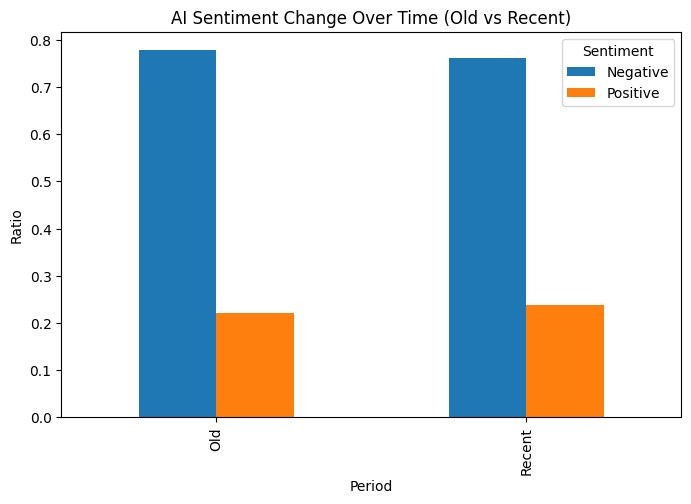


Done!


In [58]:
# -----------------------------------
# 1. VERİYİ OKU
# -----------------------------------

df = pd.read_csv("reddit_ai_comments_cleaned_final.csv")

print("Dataset:", df.shape)

# -----------------------------------
# 2. BERT MODEL
# -----------------------------------

sentiment_model = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    truncation=True
)

# -----------------------------------
# 3. SENTIMENT FONKSİYONU
# -----------------------------------

def predict(text):
    res = sentiment_model(str(text))[0]
    return res["label"], res["score"]

# -----------------------------------
# 4. HER YORUMA SENTIMENT
# -----------------------------------

results = df["Comment"].apply(predict)

df["Sentiment"] = results.apply(lambda x: x[0])
df["Confidence"] = results.apply(lambda x: x[1])

# -----------------------------------
# 5. LABEL DÜZENLE
# -----------------------------------

df["Sentiment"] = df["Sentiment"].map({
    "POSITIVE": "Positive",
    "NEGATIVE": "Negative"
})

# -----------------------------------
# 6. PERIOD BAZLI ANALİZ
# -----------------------------------

print("\n📊 Sentiment by Period:")
print(df.groupby(["Period", "Sentiment"]).size())

# -----------------------------------
# 7. ORAN HESAPLAMA (EN ÖNEMLİ KISIM)
# -----------------------------------

sentiment_ratio = df.groupby(["Period", "Sentiment"]).size().unstack()

sentiment_ratio = sentiment_ratio.div(sentiment_ratio.sum(axis=1), axis=0)

print("\n📈 Sentiment Ratios:")
print(sentiment_ratio)

# -----------------------------------
# 8. GRAFİK
# -----------------------------------

import matplotlib.pyplot as plt

sentiment_ratio.plot(kind="bar", figsize=(8,5))

plt.title("AI Sentiment Change Over Time (Old vs Recent)")
plt.ylabel("Ratio")
plt.show()

# -----------------------------------
# 9. SAVE
# -----------------------------------

df.to_csv("reddit_ai_period_sentiment.csv", index=False, encoding="utf-8-sig")

print("\nDone!")

In [59]:
# -----------------------------------
# 1. VERİYİ OKU
# -----------------------------------

df = pd.read_csv("reddit_ai_comments_cleaned_final.csv")

print("Dataset:", df.shape)

# -----------------------------------
# 2. EMOTION MODEL
# -----------------------------------

emotion_model = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=1
)

# -----------------------------------
# 3. EMOTION PREDICTION
# -----------------------------------

def get_emotion(text):
    try:
        result = emotion_model(str(text))[0][0]
        return result["label"], result["score"]
    except:
        return "unknown", 0

df["Emotion"], df["Emotion_Confidence"] = zip(
    *df["Comment"].apply(get_emotion)
)

# -----------------------------------
# 4. EMOTION DISTRIBUTION
# -----------------------------------

print(df["Emotion"].value_counts())

# -----------------------------------
# 5. PERIOD ANALYSIS
# -----------------------------------

print("\nEmotion by Period:")
print(df.groupby(["Period", "Emotion"]).size())

# -----------------------------------
# 6. SAVE
# -----------------------------------

df.to_csv("reddit_ai_emotion_results.csv", index=False, encoding="utf-8-sig")

print("Done!")

Dataset: (997, 8)


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 45651.70it/s]


Emotion
neutral     405
fear        126
joy         122
anger       120
sadness     114
surprise    101
disgust       9
Name: count, dtype: int64

Emotion by Period:
Period  Emotion 
Old     anger        42
        disgust       4
        fear         68
        joy          60
        neutral     181
        sadness      44
        surprise     44
Recent  anger        78
        disgust       5
        fear         58
        joy          62
        neutral     224
        sadness      70
        surprise     57
dtype: int64
Done!


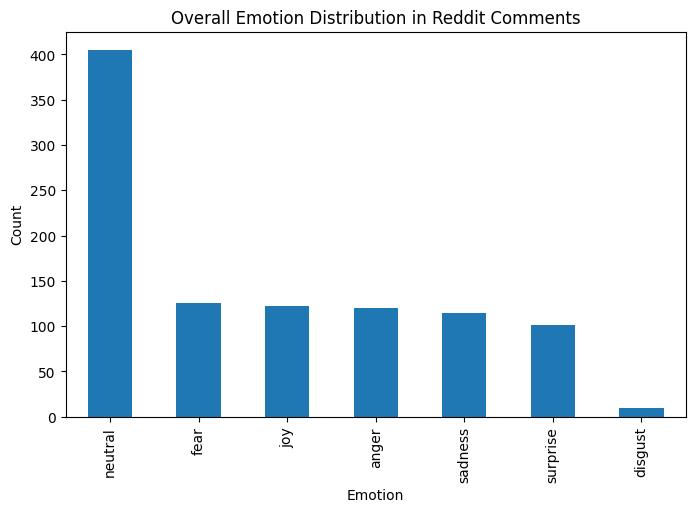

In [60]:
import matplotlib.pyplot as plt

df["Emotion"].value_counts().plot(kind="bar", figsize=(8,5))

plt.title("Overall Emotion Distribution in Reddit Comments")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

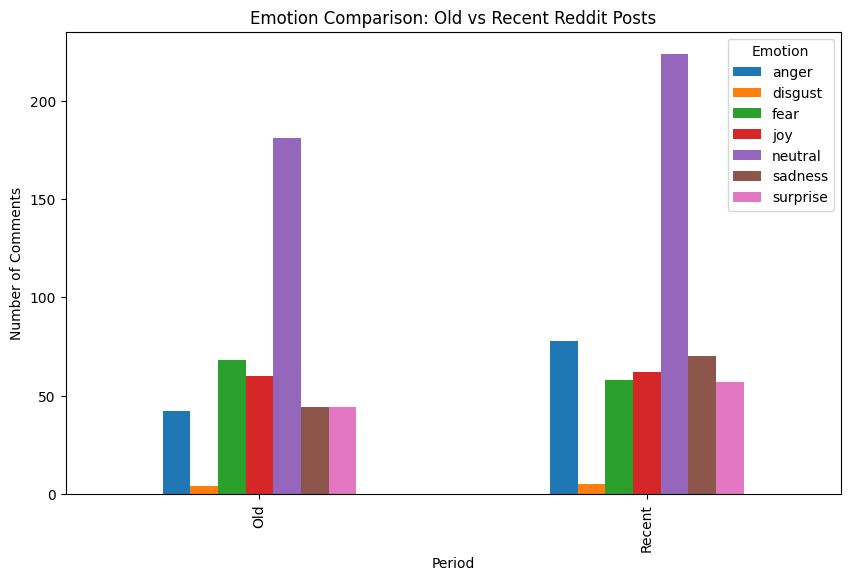

In [61]:
import matplotlib.pyplot as plt

pivot = df.pivot_table(
    index="Period",
    columns="Emotion",
    values="Comment",
    aggfunc="count"
)

pivot.plot(kind="bar", figsize=(10,6))

plt.title("Emotion Comparison: Old vs Recent Reddit Posts")
plt.ylabel("Number of Comments")
plt.xlabel("Period")
plt.show()

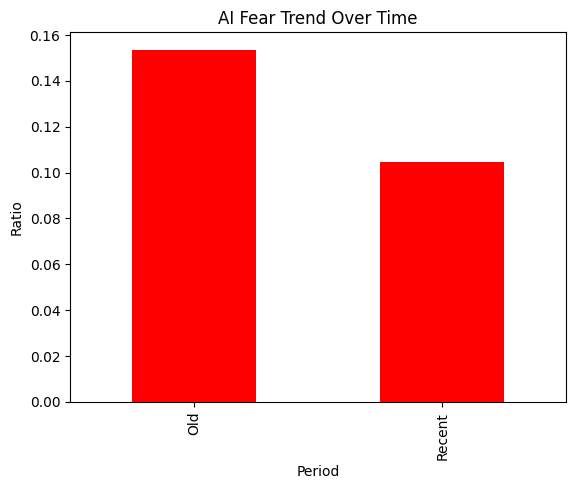

In [62]:
fear_df = df[df["Emotion"] == "fear"]

fear_ratio = df[df["Emotion"] == "fear"].groupby("Period").size() / df.groupby("Period").size()

fear_ratio.plot(kind="bar", color="red")

plt.title("AI Fear Trend Over Time")
plt.ylabel("Ratio")
plt.show()

In [63]:
#Lexicon-Based Sentiment Analysis and Bot Detection on Social Media

In [64]:
import sys
!{sys.executable} -m pip install textblob

In [65]:
import pandas as pd
from textblob import TextBlob

# -----------------------------------
# 1. VERİYİ OKU
# -----------------------------------

df = pd.read_csv("reddit_ai_comments_cleaned_final.csv")

print("Dataset:", df.shape)

# -----------------------------------
# 2. POLARITY VE SUBJECTIVITY
# -----------------------------------

def get_polarity(text):
    return TextBlob(str(text)).sentiment.polarity

def get_subjectivity(text):
    return TextBlob(str(text)).sentiment.subjectivity

# -----------------------------------
# 3. SENTIMENT CLASSIFICATION
# -----------------------------------

def get_sentiment(polarity):

    if polarity > 0.1:
        return "Positive"

    elif polarity < -0.1:
        return "Negative"

    else:
        return "Neutral"

# -----------------------------------
# 4. ANALYSIS
# -----------------------------------

df["Polarity"] = df["Comment"].apply(get_polarity)

df["Subjectivity"] = df["Comment"].apply(get_subjectivity)

df["Lexicon_Sentiment"] = df["Polarity"].apply(get_sentiment)

# -----------------------------------
# 5. SAVE RESULTS
# -----------------------------------

df.to_csv(
    "reddit_comments_sentiment_table.csv",
    index=False,
    encoding="utf-8-sig"
)

# -----------------------------------
# 6. RESULTS
# -----------------------------------

print("\nSentiment Distribution:\n")

print(df["Lexicon_Sentiment"].value_counts())

print("\nSample Results:\n")

print(
    df[
        ["Comment",
         "Polarity",
         "Subjectivity",
         "Lexicon_Sentiment"]
    ].head(20)
)

print("\n✅ File saved: reddit_comments_sentiment_table.csv")

Dataset: (997, 8)

Sentiment Distribution:

Lexicon_Sentiment
Neutral     463
Positive    427
Negative    107
Name: count, dtype: int64

Sample Results:

                                                                            Comment  Polarity  Subjectivity Lexicon_Sentiment
0   worked full time contractor video content customer support team pair tech co...  0.031347      0.427929           Neutral
1   current trajectory show around production china done robot machine mean majo...  0.036310      0.501935           Neutral
2   position essentially tasked using replace junior make work writing painfully...  0.029167      0.388194           Neutral
3           swe know coming decade job passion care already saving prepared anyways  0.000000      0.000000           Neutral
4   job warehouse automated eventually laid everyone miserable job painful pay d... -0.105556      0.811111          Negative
5   feel like follow sub realistic outlook trying best stay top posted normie th...  0.516

Dataset: (997, 8)

Sentiment Distribution:

Lexicon_Sentiment
Neutral     463
Positive    427
Negative    107
Name: count, dtype: int64


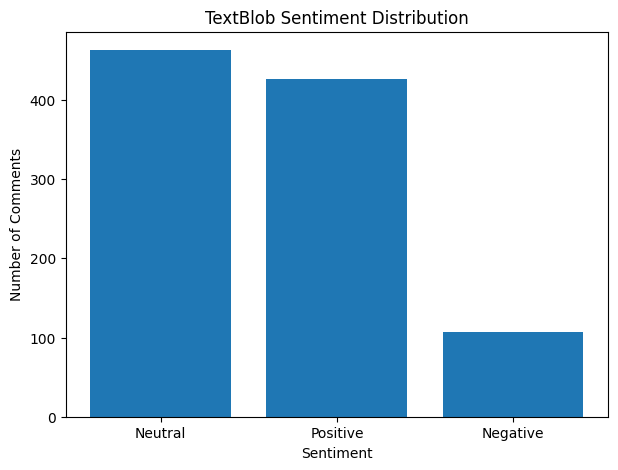

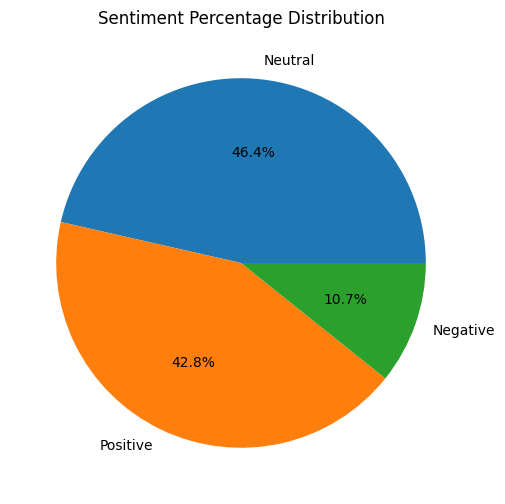

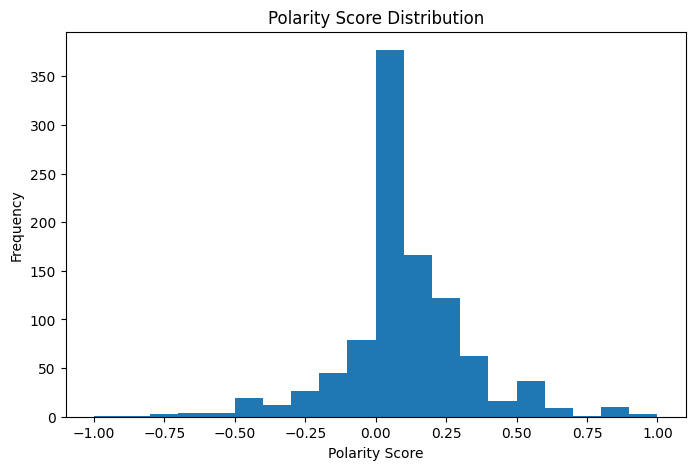

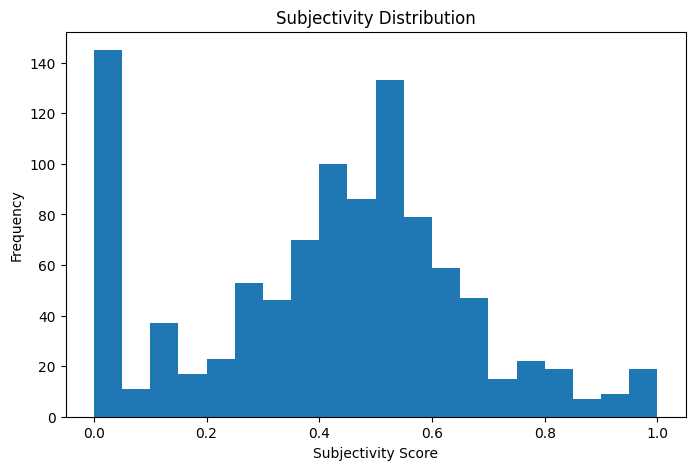


✅ Graphs created successfully!


In [66]:
# -----------------------------------
# 1. LOAD DATA
# -----------------------------------

df = pd.read_csv("reddit_ai_comments_cleaned_final.csv")

print("Dataset:", df.shape)

# -----------------------------------
# 2. FUNCTIONS
# -----------------------------------

def get_polarity(text):
    return TextBlob(str(text)).sentiment.polarity

def get_subjectivity(text):
    return TextBlob(str(text)).sentiment.subjectivity

def get_sentiment(polarity):

    if polarity > 0.1:
        return "Positive"

    elif polarity < -0.1:
        return "Negative"

    else:
        return "Neutral"

# -----------------------------------
# 3. ANALYSIS
# -----------------------------------

df["Polarity"] = df["Comment"].apply(get_polarity)

df["Subjectivity"] = df["Comment"].apply(get_subjectivity)

df["Lexicon_Sentiment"] = df["Polarity"].apply(get_sentiment)

# -----------------------------------
# 4. SAVE RESULTS
# -----------------------------------

df.to_csv(
    "reddit_comments_sentiment_table.csv",
    index=False,
    encoding="utf-8-sig"
)

# -----------------------------------
# 5. SENTIMENT COUNTS
# -----------------------------------

sentiment_counts = df["Lexicon_Sentiment"].value_counts()

print("\nSentiment Distribution:\n")
print(sentiment_counts)

# -----------------------------------
# 6. BAR CHART
# -----------------------------------

plt.figure(figsize=(7,5))

plt.bar(
    sentiment_counts.index,
    sentiment_counts.values
)

plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.title("TextBlob Sentiment Distribution")

plt.show()

# -----------------------------------
# 7. PIE CHART
# -----------------------------------

plt.figure(figsize=(6,6))

plt.pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct='%1.1f%%'
)

plt.title("Sentiment Percentage Distribution")

plt.show()

# -----------------------------------
# 8. POLARITY HISTOGRAM
# -----------------------------------

plt.figure(figsize=(8,5))

plt.hist(df["Polarity"], bins=20)

plt.xlabel("Polarity Score")
plt.ylabel("Frequency")
plt.title("Polarity Score Distribution")

plt.show()

# -----------------------------------
# 9. SUBJECTIVITY HISTOGRAM
# -----------------------------------

plt.figure(figsize=(8,5))

plt.hist(df["Subjectivity"], bins=20)

plt.xlabel("Subjectivity Score")
plt.ylabel("Frequency")
plt.title("Subjectivity Distribution")

plt.show()

print("\n✅ Graphs created successfully!")

In [67]:
#lexicon ile duygu analizi yapmaya çalıştık VADER ve NRC LEXİCON kullanmaya çalıştık ama hepsine nötr dedi 
#bizim veri setimizde işe yaramadı

In [68]:
pip install nrclex

Note: you may need to restart the kernel to use updated packages.


In [69]:
import nltk

nltk.download("punkt")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/seymanurturkkan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/seymanurturkkan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/seymanurturkkan/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [70]:
import pandas as pd
from nrclex import NRCLex

# -----------------------------------
# 1. DATA LOAD
# -----------------------------------

df = pd.read_csv("reddit_ai_comments_cleaned_final.csv")

df = df.dropna(subset=["Comment"])

print("Dataset size:", df.shape)

# -----------------------------------
# 2. NRC EMOTION FUNCTION
# -----------------------------------

def get_nrc_emotion(text):

    try:
        text = str(text)

        emotion = NRCLex(text)

        # emotion.raw_emotion_scores örnek:
        # {'fear': 2, 'anger': 1, 'joy': 3}

        if not emotion.raw_emotion_scores:
            return "neutral"

        # en yüksek skorlu duyguyu seç
        top_emotion = max(
            emotion.raw_emotion_scores,
            key=emotion.raw_emotion_scores.get
        )

        return top_emotion

    except:
        return "neutral"

# -----------------------------------
# 3. APPLY
# -----------------------------------

df["NRC_Emotion"] = df["Comment"].apply(get_nrc_emotion)

# -----------------------------------
# 4. RESULT
# -----------------------------------

print("\nEmotion distribution (NRC):\n")
print(df["NRC_Emotion"].value_counts())

# -----------------------------------
# 5. SAVE
# -----------------------------------

df.to_csv("nrc_emotion_results.csv", index=False, encoding="utf-8-sig")

print("\n✅ NRC Lexicon analysis completed!")

Dataset size: (997, 8)

Emotion distribution (NRC):

NRC_Emotion
neutral    997
Name: count, dtype: int64

✅ NRC Lexicon analysis completed!


In [71]:
import pandas as pd
import re
from nrclex import NRCLex

df = pd.read_csv("reddit_ai_comments_cleaned_final.csv")

# -----------------------------------
# 1. CLEAN TEXT (KRİTİK)
# -----------------------------------

def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text[:300]

# -----------------------------------
# 2. NRC EMOTION FUNCTION (SAFE)
# -----------------------------------

def get_emotion(text):
    try:
        text = clean_text(text).lower()

        emotion = NRCLex(text)

        scores = emotion.raw_emotion_scores

        if not scores:
            return "neutral"

        return max(scores, key=scores.get)

    except:
        return "neutral"

# -----------------------------------
# 3. APPLY (FIXED)
# -----------------------------------

df["NRC_Emotion"] = df["Comment"].apply(get_emotion)

print(df["NRC_Emotion"].value_counts())

NRC_Emotion
neutral    997
Name: count, dtype: int64


In [72]:
#BERT ve TEXTBLOB karşılaştırma

Dataset: (997, 8)

BERT sentiment analysis starting...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 70009.56it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



TextBlob sentiment analysis starting...

AGREEMENT ANALYSIS RESULTS

Agreement Rate: 43.93%

BERT Distribution:

BERT_Sentiment
Neutral     505
Negative    377
Positive    115
Name: count, dtype: int64

TextBlob Distribution:

TextBlob_Sentiment
Neutral     463
Positive    427
Negative    107
Name: count, dtype: int64

SAMPLE COMPARISON TABLE



,Comment,BERT_Sentiment,TextBlob_Sentiment,Agreement
0,worked full time contractor video content customer support team pair tech co...,Neutral,Neutral,True
1,current trajectory show around production china done robot machine mean majo...,Negative,Neutral,False
2,position essentially tasked using replace junior make work writing painfully...,Negative,Neutral,False
3,swe know coming decade job passion care already saving prepared anyways...,Neutral,Neutral,True
4,job warehouse automated eventually laid everyone miserable job painful pay d...,Negative,Negative,True
5,feel like follow sub realistic outlook trying best stay top posted normie th...,Negative,Positive,False
6,company nowadays use scapegoat lay fraction workforce...,Negative,Neutral,False
7,nobody know time scale job replaced year ready retire anyway replaced year n...,Negative,Positive,False
8,tell honestly would feel able provide family anymore come...,Neutral,Positive,False
9,replaced along people ceo said however replace work went undone search cyber...,Negative,Neutral,False



Agreement Counts:

Agreement
False    559
True     438
Name: count, dtype: int64


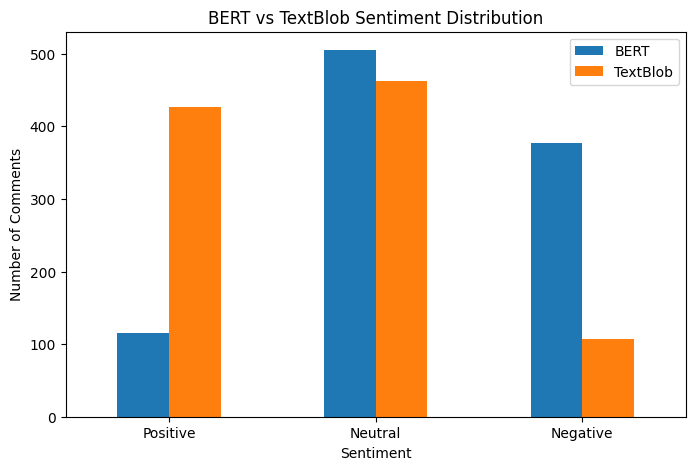

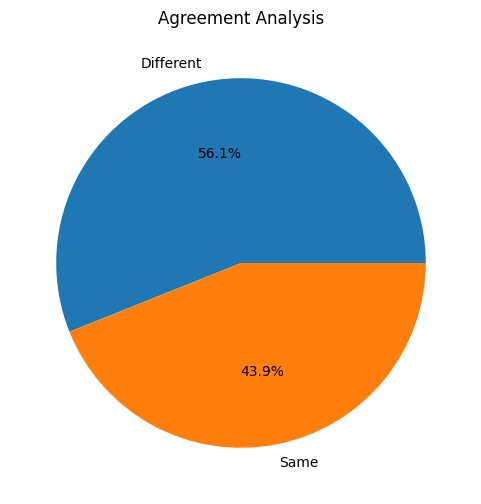


✅ File saved: bert_textblob_comparison_results.csv


In [73]:
import pandas as pd
import matplotlib.pyplot as plt

from transformers import pipeline
from textblob import TextBlob
from IPython.display import display

# -----------------------------------
# DISPLAY SETTINGS
# -----------------------------------

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1400)
pd.set_option("display.max_colwidth", 80)

# -----------------------------------
# 1. LOAD DATA
# -----------------------------------

df = pd.read_csv("reddit_ai_comments_cleaned_final.csv")

print("Dataset:", df.shape)

# -----------------------------------
# 2. BERT SENTIMENT ANALYSIS (3 CLASS)
# -----------------------------------

print("\nBERT sentiment analysis starting...")

bert_model = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    truncation=True
)

bert_labels = []
bert_scores = []

for text in df["Comment"]:

    try:
        result = bert_model(str(text))[0]

        label = result["label"].lower()
        score = result["score"]

        # LABEL CLEANING
        if label == "positive":
            final_label = "Positive"

        elif label == "negative":
            final_label = "Negative"

        else:
            final_label = "Neutral"

        bert_labels.append(final_label)
        bert_scores.append(round(score, 4))

    except:
        bert_labels.append("Neutral")
        bert_scores.append(0)

df["BERT_Sentiment"] = bert_labels
df["BERT_Confidence"] = bert_scores

# -----------------------------------
# 3. TEXTBLOB SENTIMENT ANALYSIS
# -----------------------------------

print("\nTextBlob sentiment analysis starting...")

def get_polarity(text):
    return TextBlob(str(text)).sentiment.polarity

def get_subjectivity(text):
    return TextBlob(str(text)).sentiment.subjectivity

def get_textblob_sentiment(polarity):

    if polarity > 0.1:
        return "Positive"

    elif polarity < -0.1:
        return "Negative"

    else:
        return "Neutral"

df["Polarity"] = df["Comment"].apply(get_polarity)

df["Subjectivity"] = df["Comment"].apply(
    get_subjectivity
)

df["TextBlob_Sentiment"] = df["Polarity"].apply(
    get_textblob_sentiment
)

# -----------------------------------
# 4. AGREEMENT ANALYSIS
# -----------------------------------

df["Agreement"] = (
    df["BERT_Sentiment"] ==
    df["TextBlob_Sentiment"]
)

agreement_rate = round(
    df["Agreement"].mean() * 100,
    2
)

# -----------------------------------
# 5. RESULTS
# -----------------------------------

print("\n==============================")
print("AGREEMENT ANALYSIS RESULTS")
print("==============================")

print(f"\nAgreement Rate: {agreement_rate}%")

# -----------------------------------
# 6. DISTRIBUTION COMPARISON
# -----------------------------------

print("\nBERT Distribution:\n")

print(
    df["BERT_Sentiment"]
    .value_counts()
)

print("\nTextBlob Distribution:\n")

print(
    df["TextBlob_Sentiment"]
    .value_counts()
)

# -----------------------------------
# 7. CLEAN SAMPLE TABLE
# -----------------------------------

sample_table = df[
    [
        "Comment",
        "BERT_Sentiment",
        "TextBlob_Sentiment",
        "Agreement"
    ]
].copy()

# yorumları kısalt
sample_table["Comment"] = (
    sample_table["Comment"]
    .astype(str)
    .str[:90] + "..."
)

print("\n==============================")
print("SAMPLE COMPARISON TABLE")
print("==============================\n")

display(
    sample_table.head(20)
)

# -----------------------------------
# 8. AGREEMENT COUNTS
# -----------------------------------

print("\nAgreement Counts:\n")

print(
    df["Agreement"]
    .value_counts()
)

# -----------------------------------
# 9. BAR CHART COMPARISON
# -----------------------------------

bert_counts = (
    df["BERT_Sentiment"]
    .value_counts()
)

textblob_counts = (
    df["TextBlob_Sentiment"]
    .value_counts()
)

comparison_df = pd.DataFrame({
    "BERT": bert_counts,
    "TextBlob": textblob_counts
}).fillna(0)

comparison_df = comparison_df.reindex(
    ["Positive", "Neutral", "Negative"]
)

comparison_df.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "BERT vs TextBlob Sentiment Distribution"
)

plt.xlabel("Sentiment")

plt.ylabel("Number of Comments")

plt.xticks(rotation=0)

plt.show()

# -----------------------------------
# 10. AGREEMENT PIE CHART
# -----------------------------------

agreement_counts = (
    df["Agreement"]
    .value_counts()
)

plt.figure(figsize=(6,6))

plt.pie(
    agreement_counts.values,
    labels=["Different", "Same"],
    autopct='%1.1f%%'
)

plt.title("Agreement Analysis")

plt.show()

# -----------------------------------
# 11. SAVE CSV
# -----------------------------------

df.to_csv(
    "bert_textblob_comparison_results.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "\n✅ File saved: bert_textblob_comparison_results.csv"
)

BERT: (997, 10)
TextBlob: (997, 11)

Columns: Index(['Post_Title', 'Username', 'Comment', 'Date', 'Score', 'Period', 'Bot_Score', 'Is_Bot', 'Polarity', 'Subjectivity', 'Lexicon_Sentiment'], dtype='str')

Agreement Rate: 43.93 %

DISTRIBUTION COMPARISON

          BERT (%)  TextBlob (%)
Negative     37.81         10.73
Neutral      50.65         46.44
Positive     11.53         42.83

SAMPLE:

                                                                            Comment BERT_Sentiment TextBlob_Sentiment  Agreement
0   worked full time contractor video content customer support team pair tech co...        Neutral            Neutral       True
1   current trajectory show around production china done robot machine mean majo...       Negative            Neutral      False
2   position essentially tasked using replace junior make work writing painfully...       Negative            Neutral      False
3        swe know coming decade job passion care already saving prepared anyways...     

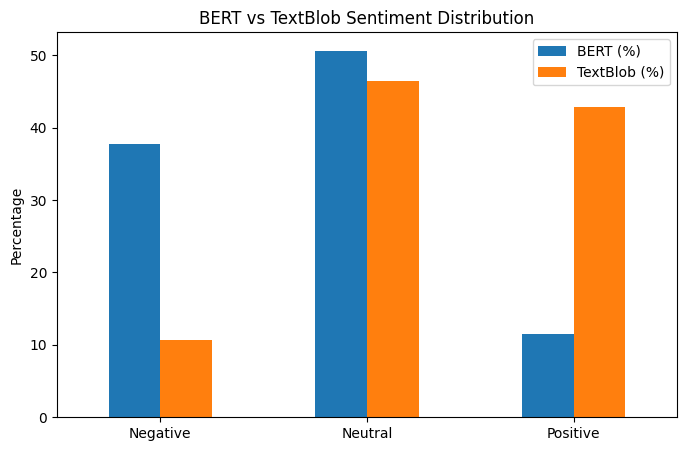


✅ DONE


In [74]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------
# LOAD DATA
# -----------------------------------

bert_df = pd.read_csv("bert_3class_results.csv")
tb_df = pd.read_csv("reddit_comments_sentiment_table.csv")

print("BERT:", bert_df.shape)
print("TextBlob:", tb_df.shape)

print("\nColumns:", tb_df.columns)

# -----------------------------------
# MERGE (DOĞRU SÜTUN)
# -----------------------------------

df = bert_df.merge(
    tb_df[["Comment", "Lexicon_Sentiment"]],
    on="Comment",
    how="inner"
)

df.rename(columns={
    "Lexicon_Sentiment": "TextBlob_Sentiment"
}, inplace=True)

# -----------------------------------
# AGREEMENT
# -----------------------------------

df["Agreement"] = df["BERT_Sentiment"] == df["TextBlob_Sentiment"]

print("\nAgreement Rate:", round(df["Agreement"].mean() * 100, 2), "%")

# -----------------------------------
# DISTRIBUTION (%)
# -----------------------------------

def pct(x):
    return (x.value_counts(normalize=True) * 100).round(2)

comparison = pd.DataFrame({
    "BERT (%)": pct(df["BERT_Sentiment"]),
    "TextBlob (%)": pct(df["TextBlob_Sentiment"])
}).fillna(0)

print("\n==============================")
print("DISTRIBUTION COMPARISON")
print("==============================\n")

print(comparison)

# -----------------------------------
# SAMPLE TABLE
# -----------------------------------

sample = df[
    ["Comment", "BERT_Sentiment", "TextBlob_Sentiment", "Agreement"]
].copy()

sample["Comment"] = sample["Comment"].astype(str).str[:80] + "..."

print("\nSAMPLE:\n")
print(sample.head(20))

# -----------------------------------
# GRAPH
# -----------------------------------

comparison.plot(kind="bar", figsize=(8,5))
plt.title("BERT vs TextBlob Sentiment Distribution")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

# -----------------------------------
# SAVE
# -----------------------------------

df.to_csv("final_comparison.csv", index=False)

print("\n✅ DONE")

In [75]:
#İLK TEMİZLENMİŞ VERİLER!!!
import pandas as pd

df = pd.read_csv("reddit_ai_comments_cleaned_final.csv")

# 100 örnek seç
sample = df[["Comment"]].sample(100, random_state=42)

# HUMAN LABEL SÜTUNU EKLE
sample["Human_Label"] = ""

# kaydet
sample.to_csv("human_labels.csv", index=False)

print("human_labels.csv hazır!")

human_labels.csv hazır!


In [76]:
import pandas as pd

# mevcut etiketli veri
try:
    labeled = pd.read_csv("human_labels.csv")
except FileNotFoundError:
    labeled = pd.DataFrame(columns=["Comment", "Human_Label"])

# ana dataset
df = pd.read_csv("reddit_ai_comments_cleaned_final.csv")

# daha önce eklenmeyenleri al
remaining = df[~df["Comment"].isin(labeled["Comment"])]

# yeni 100 veri seç
new_batch = remaining[["Comment"]].sample(100, random_state=42)
new_batch["Human_Label"] = ""   # sen manuel dolduracaksın

# birleştir
updated = pd.concat([labeled, new_batch], ignore_index=True)

# güvenlik: duplicate engelle
updated = updated.drop_duplicates(subset=["Comment"])

# kaydet
updated.to_csv("human_labels.csv", index=False)

print("100 yeni yorum eklendi, manuel etiketlemeye hazır")

100 yeni yorum eklendi, manuel etiketlemeye hazır


BERT dataset: (997, 10)
TextBlob dataset: (997, 11)
Human dataset: (200, 2)

Merged dataset: (200, 12)

Merged dataset: (200, 12)

MODEL ACCURACY COMPARISON

BERT Accuracy: 0.00%
TextBlob Accuracy: 0.00%

Model Agreement Rate: 38.50%

SENTIMENT DISTRIBUTION

          BERT (%)  TextBlob (%)  Human (%)
Negative      45.0          10.5        0.0
Neutral       43.5          47.0        0.0
Positive      11.5          42.5        0.0

SAMPLE COMPARISON TABLE

                                                                      Comment BERT_Sentiment TextBlob_Sentiment Human_Label
0   hopefully short term pain long term gain thing mean alternative work b...        Neutral           Negative         NaN
1   job replaced hope society made swtich job required know optimistic sce...        Neutral            Neutral         NaN
2                                            soon gonna government problem...       Negative            Neutral         NaN
3   major growing pain humanity eventually 

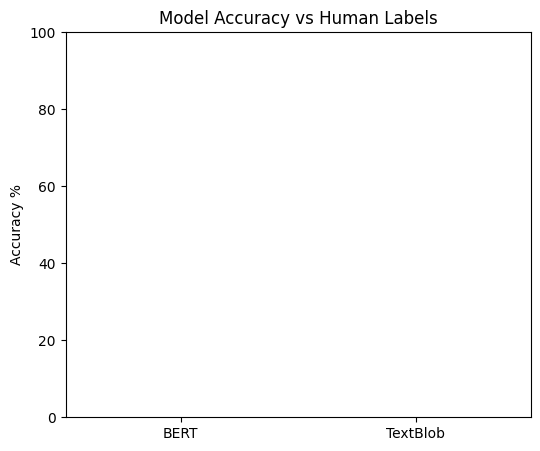

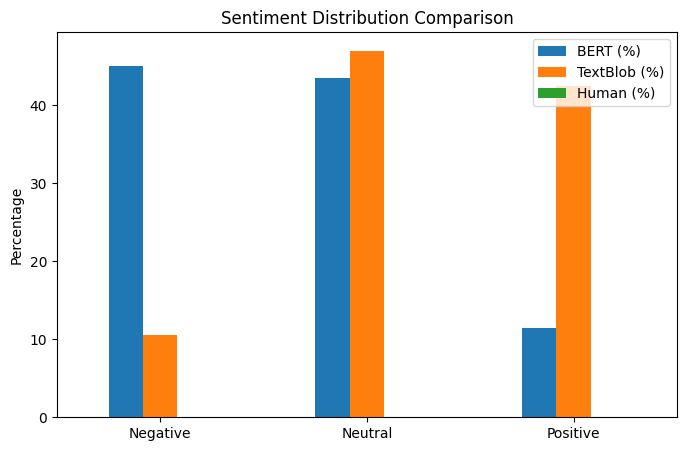


BERT WRONG PREDICTIONS

                                                                                                                                                                        Comment BERT_Sentiment Human_Label
0                                                                   hopefully short term pain long term gain thing mean alternative work button year retire maybe year less die        Neutral         NaN
1                             job replaced hope society made swtich job required know optimistic scenario also live country gonna slow adapting might later sooner get replaced        Neutral         NaN
2                                                                                                                                                 soon gonna government problem       Negative         NaN
3                                                       major growing pain humanity eventually adapt whole new cooperative way life think like hunte living technol

In [77]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------
# 1. LOAD DATASETS
# -----------------------------------

bert_df = pd.read_csv("bert_3class_results.csv")
tb_df = pd.read_csv("reddit_comments_sentiment_table.csv")
human_df = pd.read_csv("human_labels.csv")

print("BERT dataset:", bert_df.shape)
print("TextBlob dataset:", tb_df.shape)
print("Human dataset:", human_df.shape)

# -----------------------------------
# 2. COLUMN FIX
# -----------------------------------

tb_df.rename(columns={
    "Lexicon_Sentiment": "TextBlob_Sentiment"
}, inplace=True)

# -----------------------------------
# 3. MERGE ALL DATASETS
# -----------------------------------

df = bert_df.merge(
    tb_df[["Comment", "TextBlob_Sentiment"]],
    on="Comment",
    how="inner"
)

df = df.merge(
    human_df[["Comment", "Human_Label"]],
    on="Comment",
    how="inner"
)

print("\nMerged dataset:", df.shape)

print("\nMerged dataset:", df.shape)

# -----------------------------------
# LABEL CLEANING
# -----------------------------------

df["BERT_Sentiment"] = (
    df["BERT_Sentiment"]
    .astype(str)
    .str.strip()
)

df["TextBlob_Sentiment"] = (
    df["TextBlob_Sentiment"]
    .astype(str)
    .str.strip()
)

df["Human_Label"] = (
    df["Human_Label"]
    .astype(str)
    .str.strip()
)

# -----------------------------------
# 4. ACCURACY CALCULATION
# -----------------------------------

bert_accuracy = (
    (df["BERT_Sentiment"] == df["Human_Label"])
    .mean() * 100
)

textblob_accuracy = (
    (df["TextBlob_Sentiment"] == df["Human_Label"])
    .mean() * 100
)

print("\n==============================")
print("MODEL ACCURACY COMPARISON")
print("==============================")

print(f"\nBERT Accuracy: {bert_accuracy:.2f}%")
print(f"TextBlob Accuracy: {textblob_accuracy:.2f}%")

# -----------------------------------
# 5. AGREEMENT ANALYSIS
# -----------------------------------

df["Agreement"] = (
    df["BERT_Sentiment"] ==
    df["TextBlob_Sentiment"]
)

agreement_rate = df["Agreement"].mean() * 100

print(f"\nModel Agreement Rate: {agreement_rate:.2f}%")

# -----------------------------------
# 6. DISTRIBUTION COMPARISON
# -----------------------------------

def percentage(col):
    return (
        col.value_counts(normalize=True) * 100
    ).round(2)

distribution = pd.DataFrame({
    "BERT (%)":
        percentage(df["BERT_Sentiment"]),

    "TextBlob (%)":
        percentage(df["TextBlob_Sentiment"]),

    "Human (%)":
        percentage(df["Human_Label"])
}).fillna(0)

print("\n==============================")
print("SENTIMENT DISTRIBUTION")
print("==============================\n")

print(distribution)

# -----------------------------------
# 7. SAMPLE TABLE
# -----------------------------------

sample = df[
    [
        "Comment",
        "BERT_Sentiment",
        "TextBlob_Sentiment",
        "Human_Label"
    ]
].copy()

sample["Comment"] = (
    sample["Comment"]
    .astype(str)
    .str[:70] + "..."
)

print("\n==============================")
print("SAMPLE COMPARISON TABLE")
print("==============================\n")

print(sample.head(20).to_string())

# -----------------------------------
# 8. ACCURACY GRAPH
# -----------------------------------

models = ["BERT", "TextBlob"]
scores = [bert_accuracy, textblob_accuracy]

plt.figure(figsize=(6,5))

plt.bar(models, scores)

plt.ylabel("Accuracy %")
plt.ylim(0, 100)

plt.title("Model Accuracy vs Human Labels")

plt.show()

# -----------------------------------
# 9. DISTRIBUTION GRAPH
# -----------------------------------

distribution.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Sentiment Distribution Comparison")
plt.ylabel("Percentage")

plt.xticks(rotation=0)

plt.show()

# -----------------------------------
# 10. WRONG PREDICTIONS
# -----------------------------------

print("\n==============================")
print("BERT WRONG PREDICTIONS")
print("==============================\n")

bert_wrong = df[
    df["BERT_Sentiment"] != df["Human_Label"]
]

print(
    bert_wrong[
        [
            "Comment",
            "BERT_Sentiment",
            "Human_Label"
        ]
    ].head(10).to_string()
)

print("\n==============================")
print("TEXTBLOB WRONG PREDICTIONS")
print("==============================\n")

tb_wrong = df[
    df["TextBlob_Sentiment"] != df["Human_Label"]
]

print(
    tb_wrong[
        [
            "Comment",
            "TextBlob_Sentiment",
            "Human_Label"
        ]
    ].head(10).to_string()
)

# -----------------------------------
# 11. SAVE FINAL RESULTS
# -----------------------------------

df.to_csv(
    "final_human_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n✅ File saved: final_human_comparison.csv")

In [78]:
#ÜRÜN YORUMU DENEME

In [79]:
from datetime import datetime
#0-6 ay redditler

# İncelenecek gönderiler
posts = [
    {
        "url": "https://www.reddit.com/r/iphone17/comments/1szko2w/bought_iphone_17_instead_of_oneplus_15_and/",
    },
    {
        "url": "https://www.reddit.com/r/iPhone15Pro/comments/1rjwntg/honest_review/",
    },
    {
        "url": "https://www.reddit.com/r/iphone/comments/1jsqlrk/the_iphone_15_pro_max_is_the_worst_iphone_ive/",
    }
]

# Tüm yorumları saklayacağımız liste
all_comments = []

# Her gönderi için
for post in posts:

    submission = reddit.submission(url=post["url"])

    submission.comments.replace_more(limit=0)

    print(f"Post çekiliyor: {submission.title}")

    # TÜM yorumlar
    for comment in submission.comments.list():

        # deleted yorumları atla
        if comment.body in ["[deleted]", "[removed]"]:
            continue

        # Username
        if comment.author:
            username = comment.author.name
        else:
            username = "deleted"

        # Tarih
        comment_date = datetime.fromtimestamp(
            comment.created_utc
        ).strftime('%Y-%m-%d')

        # Listeye ekle
        all_comments.append({
            "Post_Title": submission.title,
            "Username": username,
            "Comment": comment.body,
            "Date": comment_date,
            "Score": comment.score,
        })

# DataFrame
df_recent = pd.DataFrame(all_comments)

# CSV kaydet
df_recent.to_csv(
    "reddit_iphone15_comments.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Recent yorumlar kaydedildi!")
print(df_recent.shape)
print(df_recent.head())

NameError: name 'reddit' is not defined

In [ ]:
import pandas as pd
import re
import emoji
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# -----------------------------------
# NLTK DOWNLOADS
# -----------------------------------

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# -----------------------------------
# 1. VERİYİ OKU
# -----------------------------------

df = pd.read_csv("reddit_iphone15_comments.csv")

print("Başlangıç veri boyutu:", df.shape)

# -----------------------------------
# 2. STOPWORDS & LEMMATIZER
# -----------------------------------

stop_words = set(stopwords.words('english'))

custom_stopwords = {
    'ai', 'artificial', 'intelligence',
    'reddit', 'comment', 'deleted',
    'removed', 'user'
}

stop_words.update(custom_stopwords)

lemmatizer = WordNetLemmatizer()

# -----------------------------------
# 3. TEXT CLEANING FUNCTION
# -----------------------------------

def clean_text(text):

    text = str(text)

    # Lowercase
    text = text.lower()

    # URL kaldır
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text)

    # Reddit mentions/subreddit
    text = re.sub(r'u\/\w+', ' ', text)
    text = re.sub(r'r\/\w+', ' ', text)

    # HTML temizleme
    text = re.sub(r'<.*?>', ' ', text)

    # Emoji kaldır
    text = emoji.replace_emoji(text, replace=' ')

    # Sayıları kaldır
    text = re.sub(r'\d+', ' ', text)

    # Noktalama & özel karakter
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Tekrarlayan harfleri azalt
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # Fazla boşluk
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization
    words = text.split()

    # Stopword removal + kısa kelime kaldır
    words = [
        word for word in words
        if word not in stop_words and len(word) > 2
    ]

    # Lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

# -----------------------------------
# 4. CLEANING UYGULA
# -----------------------------------

df["Comment"] = df["Comment"].apply(clean_text)

# -----------------------------------
# 5. BOŞ / KISA YORUM SİL
# -----------------------------------

df = df[df["Comment"].str.len() > 15]

# -----------------------------------
# 6. DUPLICATE YORUM SİL
# -----------------------------------

df = df.drop_duplicates(subset=["Comment"])

# -----------------------------------
# 7. RESET INDEX
# -----------------------------------

df = df.reset_index(drop=True)

# -----------------------------------
# 8. SONUÇ
# -----------------------------------

print("Temizlenmiş veri boyutu:", df.shape)

print(df.head())

# -----------------------------------
# 9. KAYDET
# -----------------------------------

df.to_csv(
    "iphone15_comments_cleaned.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Yeni temizlenmiş dataset kaydedildi!")

Başlangıç veri boyutu: (243, 5)
Temizlenmiş veri boyutu: (214, 5)
                                                                   Post_Title              Username                                                                          Comment        Date  Score
0  Bought iPhone 17 instead of Oneplus 15 and heavily regretting the decision  Fearless_Purchase406  want impressive fancy stuff would take samsung base using want often play ga...  2026-04-30     20
1  Bought iPhone 17 instead of Oneplus 15 and heavily regretting the decision            robblake44  question switch iphone loved android curious iphone pretty much whole way bu...  2026-04-30     20
2  Bought iPhone 17 instead of Oneplus 15 and heavily regretting the decision               Ash16pm  sorry found great one best iphones ever battery life great last day remember...  2026-04-30     21
3  Bought iPhone 17 instead of Oneplus 15 and heavily regretting the decision   Soviet-Anime-Hunter  wanna ruin thing oneplus shutting

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/seymanurturkkan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/seymanurturkkan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/seymanurturkkan/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
import pandas as pd
from transformers import pipeline
from IPython.display import display

# -----------------------------------
# 1. LOAD DATA
# -----------------------------------

df = pd.read_csv("iphone15_comments_cleaned.csv")

print("Dataset:", df.shape)

# -----------------------------------
# 2. LOAD BERT MODEL (3 CLASS)
# -----------------------------------

print("\nLoading BERT model...")

sentiment_model = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    truncation=True
)

# -----------------------------------
# 3. BERT SENTIMENT ANALYSIS
# -----------------------------------

bert_labels = []
bert_scores = []

print("\nRunning sentiment analysis...")

for text in df["Comment"]:

    try:
        result = sentiment_model(str(text))[0]

        label = result["label"].lower()
        score = result["score"]

        # LABEL CLEANING
        if label == "positive":
            final_label = "Positive"

        elif label == "negative":
            final_label = "Negative"

        else:
            final_label = "Neutral"

        bert_labels.append(final_label)
        bert_scores.append(round(score, 4))

    except:
        bert_labels.append("Neutral")
        bert_scores.append(0)

# -----------------------------------
# 4. SAVE RESULTS TO DATAFRAME
# -----------------------------------

df["BERT_Sentiment"] = bert_labels
df["Confidence"] = bert_scores

average_confidence = df["Confidence"].mean()

print(
    "Average Confidence: %",
    round(average_confidence * 100, 2)
)

# -----------------------------------
# 5. SENTIMENT DISTRIBUTION
# -----------------------------------

print("\n==============================")
print("BERT SENTIMENT DISTRIBUTION")
print("==============================\n")

print(df["BERT_Sentiment"].value_counts())

# -----------------------------------
# 6. CREATE CLEAN TABLE
# -----------------------------------

comparison_table = df[
    [
        "Comment",
        "BERT_Sentiment",
        "Confidence"
    ]
].copy()

# Yorumları kısalt
comparison_table["Comment"] = (
    comparison_table["Comment"]
    .astype(str)
    .str[:90] + "..."
)

# -----------------------------------
# 7. DISPLAY TABLE
# -----------------------------------

print("\n==============================")
print("SAMPLE RESULTS")
print("==============================\n")

display(
    comparison_table.head(20)
)

# -----------------------------------
# 8. STYLED TABLE (OPTIONAL)
# -----------------------------------

styled_table = comparison_table.head(50).style.background_gradient(
    subset=["Confidence"]
)

display(styled_table)

# -----------------------------------
# 9. SAVE CSV
# -----------------------------------

df.to_csv(
    "iphone15_bert_3class_results.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n✅ File saved: iphone15_bert_3class_results.csv")

Dataset: (214, 5)

Loading BERT model...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 51778.35it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Running sentiment analysis...
Average Confidence: % 72.5

BERT SENTIMENT DISTRIBUTION

BERT_Sentiment
Positive    77
Neutral     70
Negative    67
Name: count, dtype: int64

SAMPLE RESULTS



,Comment,BERT_Sentiment,Confidence
0,want impressive fancy stuff would take samsung base using want often play ga...,Neutral,0.4635
1,question switch iphone loved android curious iphone pretty much whole way bu...,Positive,0.8973
2,sorry found great one best iphones ever battery life great last day remember...,Positive,0.8688
3,wanna ruin thing oneplus shutting part unless alright last phone better goin...,Negative,0.7818
4,face siri work good one swipe search enough stay apple instead samsung andro...,Neutral,0.4999
5,hardcore android issue android choose iphone first place know big battery si...,Neutral,0.6081
6,iphone nearly month got hot average hr screen time daily battery youtube cal...,Positive,0.9526
7,always sell buy oneplus...,Neutral,0.6684
8,iphone android samsung honor infinix say true battery life base decent way b...,Positive,0.5362
9,used oneplus half month battery amazing missed io software lmao camera avera...,Positive,0.5582


,Comment,BERT_Sentiment,Confidence
0,want impressive fancy stuff would take samsung base using want often play game perfect hea...,Neutral,0.463500
1,question switch iphone loved android curious iphone pretty much whole way buddy got deal s...,Positive,0.897300
2,sorry found great one best iphones ever battery life great last day remember small phone t...,Positive,0.868800
3,wanna ruin thing oneplus shutting part unless alright last phone better going another bran...,Negative,0.781800
4,face siri work good one swipe search enough stay apple instead samsung android might bootl...,Neutral,0.499900
5,hardcore android issue android choose iphone first place know big battery size difference ...,Neutral,0.608100
6,iphone nearly month got hot average hr screen time daily battery youtube call texting shop...,Positive,0.952600
7,always sell buy oneplus...,Neutral,0.668400
8,iphone android samsung honor infinix say true battery life base decent way better samsung ...,Positive,0.536200
9,used oneplus half month battery amazing missed io software lmao camera average opposite bo...,Positive,0.558200



✅ File saved: iphone15_bert_3class_results.csv


In [ ]:
import pandas as pd

df = pd.read_csv("iphone15_comments_cleaned.csv")

# 50 örnek seç
sample = df[["Comment"]].sample(50, random_state=42)

# HUMAN LABEL SÜTUNU EKLE
sample["Human_Label"] = ""

# kaydet
sample.to_csv("human_labels_iphone15.csv", index=False)

print("human_labels_iphoen15.csv hazır!")

human_labels_iphoen15.csv hazır!


BERT dataset: (214, 7)
Human dataset: (50, 2)

Merged dataset: (50, 8)

BERT vs HUMAN ACCURACY

BERT Accuracy: nan%

Agreement Rate: nan%

SENTIMENT DISTRIBUTION

Empty DataFrame
Columns: [BERT (%), Human (%)]
Index: []

SAMPLE COMPARISON

Empty DataFrame
Columns: [Comment, BERT_Sentiment, Human_Label]
Index: []


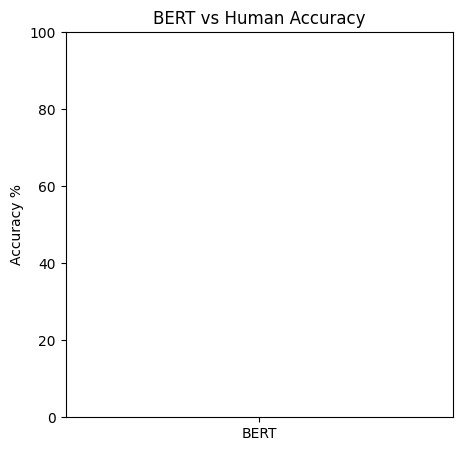

IndexError: index 0 is out of bounds for axis 0 with size 0

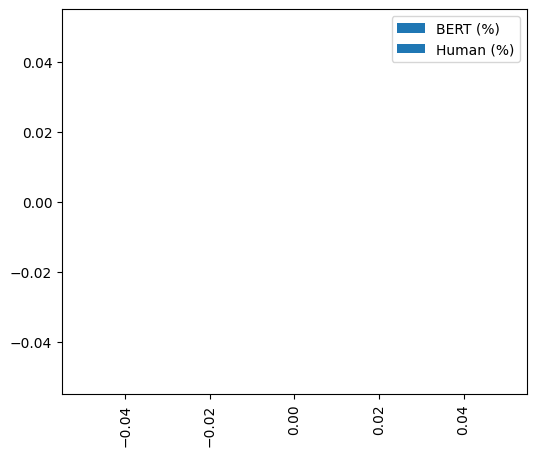

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------
# 1. LOAD DATASETS
# -----------------------------------

bert_df = pd.read_csv("iphone15_bert_3class_results.csv")
human_df = pd.read_csv("human_labels_iphone15.csv")

print("BERT dataset:", bert_df.shape)
print("Human dataset:", human_df.shape)

# -----------------------------------
# 2. MERGE DATASETS
# -----------------------------------

df = bert_df.merge(
    human_df[["Comment", "Human_Label"]],
    on="Comment",
    how="inner"
)

print("\nMerged dataset:", df.shape)

# -----------------------------------
# 3. CLEAN LABELS
# -----------------------------------

df["BERT_Sentiment"] = df["BERT_Sentiment"].astype(str).str.strip()
df["Human_Label"] = df["Human_Label"].astype(str).str.strip()

# NaN temizliği
df = df.dropna(subset=["BERT_Sentiment", "Human_Label"])

# -----------------------------------
# 4. ACCURACY CALCULATION
# -----------------------------------

bert_accuracy = (df["BERT_Sentiment"] == df["Human_Label"]).mean() * 100

print("\n==============================")
print("BERT vs HUMAN ACCURACY")
print("==============================")

print(f"\nBERT Accuracy: {bert_accuracy:.2f}%")

# -----------------------------------
# 5. AGREEMENT ANALYSIS (optional but useful)
# -----------------------------------

df["Agreement"] = df["BERT_Sentiment"] == df["Human_Label"]
agreement_rate = df["Agreement"].mean() * 100

print(f"\nAgreement Rate: {agreement_rate:.2f}%")

# -----------------------------------
# 6. DISTRIBUTION ANALYSIS
# -----------------------------------

def percentage(col):
    return (col.value_counts(normalize=True) * 100).round(2)

distribution = pd.DataFrame({
    "BERT (%)": percentage(df["BERT_Sentiment"]),
    "Human (%)": percentage(df["Human_Label"])
}).fillna(0)

print("\n==============================")
print("SENTIMENT DISTRIBUTION")
print("==============================\n")

print(distribution)

# -----------------------------------
# 7. SAMPLE TABLE
# -----------------------------------

sample = df[["Comment", "BERT_Sentiment", "Human_Label"]].copy()
sample["Comment"] = sample["Comment"].astype(str).str[:70] + "..."

print("\n==============================")
print("SAMPLE COMPARISON")
print("==============================\n")

print(sample.head(20).to_string())

# -----------------------------------
# 8. ACCURACY GRAPH
# -----------------------------------

plt.figure(figsize=(5,5))
plt.bar(["BERT"], [bert_accuracy])

plt.ylabel("Accuracy %")
plt.ylim(0, 100)
plt.title("BERT vs Human Accuracy")

plt.show()

# -----------------------------------
# 9. DISTRIBUTION GRAPH
# -----------------------------------

distribution.plot(kind="bar", figsize=(6,5))
plt.title("Sentiment Distribution (BERT vs Human)")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

# -----------------------------------
# 10. WRONG PREDICTIONS
# -----------------------------------

print("\n==============================")
print("WRONG PREDICTIONS (BERT)")
print("==============================\n")

wrong = df[df["BERT_Sentiment"] != df["Human_Label"]]

print(
    wrong[["Comment", "BERT_Sentiment", "Human_Label"]]
    .head(10)
    .to_string()
)

# -----------------------------------
# 11. SAVE FINAL RESULTS
# -----------------------------------

df.to_csv(
    "final_bert_human_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n✅ File saved: final_bert_human_comparison.csv")